# 04 _ Final Comparison

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, f1_score,
)

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
# Load data + tuning results
config = json.loads((DATA_DIR / "config.json").read_text())
tuning = json.loads((DATA_DIR / "tuning_results.json").read_text())
baseline = json.loads((DATA_DIR / "baseline_results.json").read_text())
selected_features = config["selected_features"]

df = pd.read_csv(DATA_DIR / "df.csv")
df["t_win"] = df.round_winner.astype("category").cat.codes

X = df[selected_features]
y = df["t_win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train.values, test_size=0.15, random_state=42
)

X_tr_t = torch.FloatTensor(X_tr).to(device)
y_tr_t = torch.FloatTensor(y_tr).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test.values).to(device)

n_features = X_tr.shape[1]
print("Tuning results loaded. Training final models...")

Tuning results loaded. Training final models...


/var/folders/g_/308hrlgs3116kkpyjkr3fkfr0000gn/T/ipykernel_85420/1651347138.py:27: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:209.)
  y_test_t = torch.FloatTensor(y_test.values).to(device)


## Train Models with good Params

In [6]:
# Model definitions (same as notebook 02 and 03)
class MLP(nn.Module):
    def __init__(self, n_features, hidden=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

class GRUModel(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.gru(x)
        return torch.sigmoid(self.fc(out[:, -1, :])).squeeze(-1)

class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        return torch.sigmoid(self.fc(out[:, -1, :])).squeeze(-1)


def train_final(model, X_tr_t, y_tr_t, X_val_t, y_val_t, epochs=60, patience=10, lr=1e-3, batch_size=256):
    """Train with early stopping, return history."""
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    best_val_loss = float("inf")
    wait = 0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            vp = model(X_val_t)
            vl = criterion(vp, y_val_t).item()
            va = ((vp > 0.5).float() == y_val_t).float().mean().item()

        history["train_loss"].append(epoch_loss / len(loader))
        history["val_loss"].append(vl)
        history["val_acc"].append(va)

        if vl < best_val_loss:
            best_val_loss = vl
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return history

In [7]:
# Random Forest best params from tuning
rf_params = tuning["Random Forest"]["best_params"]
print(f"Training RF with {rf_params}")
rf = RandomForestClassifier(**rf_params, n_jobs=-1, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]
rf_acc = rf.score(X_test_scaled, y_test)
print(f"RF test accuracy: {rf_acc:.4f}\n")

# MLP
mlp_p = tuning["MLP"]["best_params"]
print(f"Training MLP with hidden={mlp_p['hidden']}, lr={mlp_p['lr']}")
mlp = MLP(n_features, hidden=mlp_p["hidden"]).to(device)
mlp_hist = train_final(mlp, X_tr_t, y_tr_t, X_val_t, y_val_t, lr=mlp_p["lr"])
mlp.eval()
with torch.no_grad():
    mlp_probs = mlp(X_test_t).cpu().numpy()
mlp_acc = accuracy_score(y_test, (mlp_probs > 0.5).astype(int))
print(f"MLP test accuracy: {mlp_acc:.4f}\n")

# GRU
gru_p = tuning["GRU"]["best_params"]
print(f"Training GRU with hidden={gru_p['hidden']}, lr={gru_p['lr']}")
gru = GRUModel(n_features, hidden=gru_p["hidden"]).to(device)
gru_hist = train_final(gru, X_tr_t, y_tr_t, X_val_t, y_val_t, lr=gru_p["lr"])
gru.eval()
with torch.no_grad():
    gru_probs = gru(X_test_t).cpu().numpy()
gru_acc = accuracy_score(y_test, (gru_probs > 0.5).astype(int))
print(f"GRU test accuracy: {gru_acc:.4f}\n")

# LSTM
lstm_p = tuning["LSTM"]["best_params"]
print(f"Training LSTM with hidden={lstm_p['hidden']}, lr={lstm_p['lr']}")
lstm = LSTMModel(n_features, hidden=lstm_p["hidden"]).to(device)
lstm_hist = train_final(lstm, X_tr_t, y_tr_t, X_val_t, y_val_t, lr=lstm_p["lr"])
lstm.eval()
with torch.no_grad():
    lstm_probs = lstm(X_test_t).cpu().numpy()
lstm_acc = accuracy_score(y_test, (lstm_probs > 0.5).astype(int))
print(f"LSTM test accuracy: {lstm_acc:.4f}")

Training RF with {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 500}
RF test accuracy: 0.8315

Training MLP with hidden=256, lr=0.0005
MLP test accuracy: 0.7599

Training GRU with hidden=64, lr=0.005
GRU test accuracy: 0.7502

Training LSTM with hidden=64, lr=0.005
LSTM test accuracy: 0.7545


## Comparison

In [9]:
final = {
    "Random Forest": {"acc": rf_acc, "probs": rf_probs},
    "MLP": {"acc": mlp_acc, "probs": mlp_probs},
    "GRU": {"acc": gru_acc, "probs": gru_probs},
    "LSTM": {"acc": lstm_acc, "probs": lstm_probs},
}
y_true = y_test.values

print("=" * 53)
print(f"{'Model':<20} {'Baseline':>10} {'Tuned':>10} {'Delta':>10}")
print("=" * 53)
for name in final:
    base = baseline.get(name, 0)
    tuned = final[name]["acc"]
    delta = tuned - base
    print(f"{name:<20} {base:>10.4f} {tuned:>10.4f} {delta:>+10.4f}")
print("=" * 53)

Model                  Baseline      Tuned      Delta
Random Forest            0.8288     0.8315    +0.0027
MLP                      0.7551     0.7599    +0.0048
GRU                      0.7505     0.7502    -0.0003
LSTM                     0.7512     0.7545    +0.0033


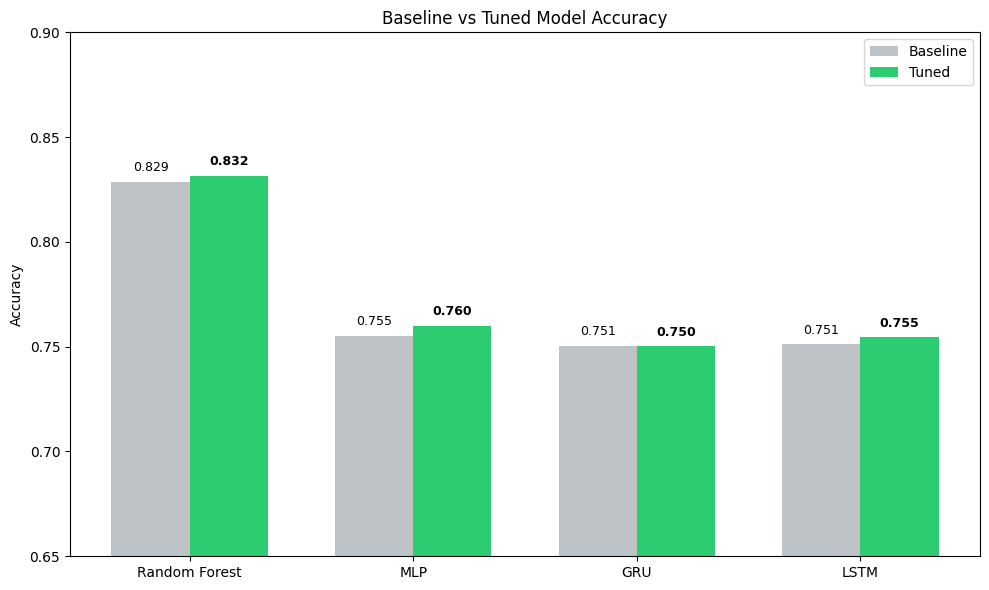

In [10]:
# Accuracy comparison, baseline vs tuned
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(final))
width = 0.35
names = list(final.keys())

base_accs = [baseline.get(n, 0) for n in names]
tuned_accs = [final[n]["acc"] for n in names]

ax.bar(x - width/2, base_accs, width, label="Baseline", color="#bdc3c7")
ax.bar(x + width/2, tuned_accs, width, label="Tuned", color="#2ecc71")

ax.set_ylabel("Accuracy")
ax.set_title("Baseline vs Tuned Model Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.set_ylim(0.65, 0.90)

for i, (b, t) in enumerate(zip(base_accs, tuned_accs)):
    ax.text(i - width/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

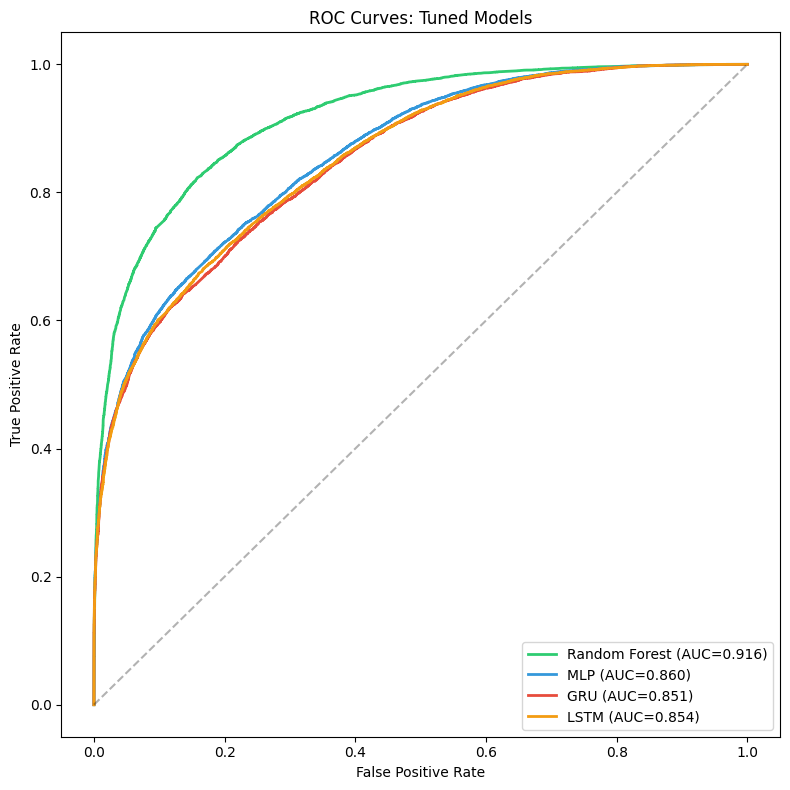

In [11]:
# ROC curves from tutorial
fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]

for (name, r), color in zip(final.items(), colors):
    fpr, tpr, _ = roc_curve(y_true, r["probs"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: Tuned Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

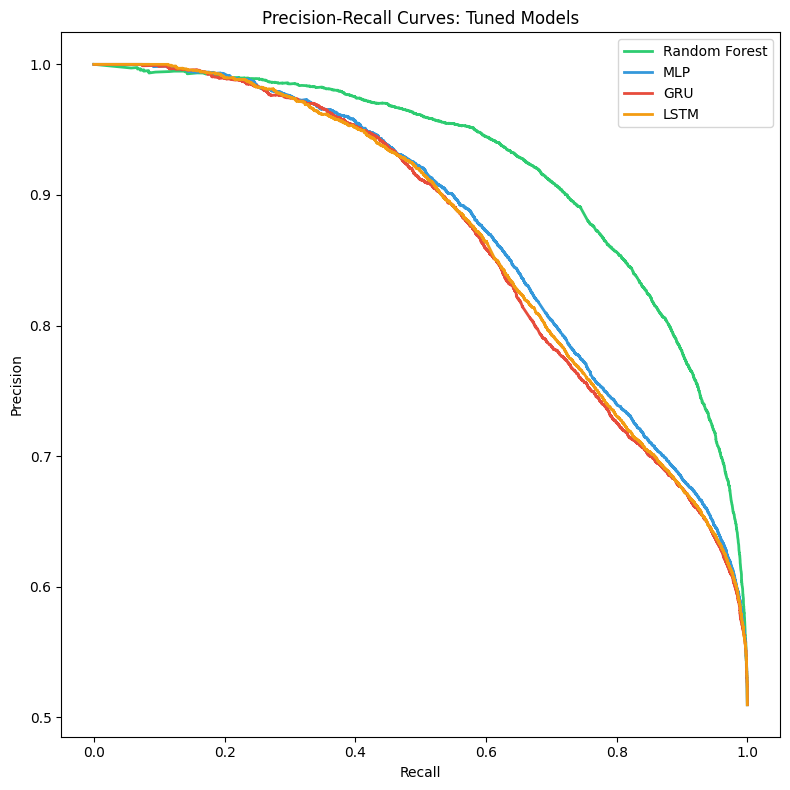

In [ ]:
# Precision Recall curves from tutorial
fig, ax = plt.subplots(figsize=(8, 8))

for (name, r), color in zip(final.items(), colors):
    precision, recall, _ = precision_recall_curve(y_true, r["probs"])
    ax.plot(recall, precision, label=name, color=color, linewidth=2)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves: Tuned Models")
ax.legend()
plt.tight_layout()
plt.show()

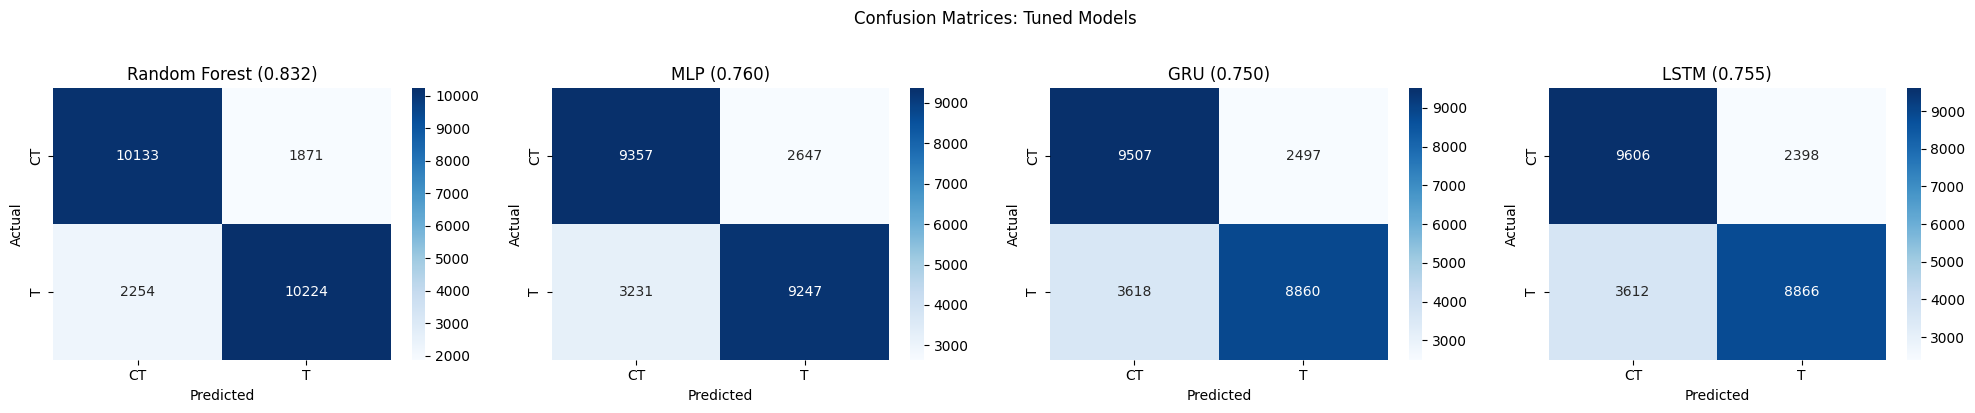

In [14]:
# Confusion matrices from tutorial
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, r) in zip(axes, final.items()):
    preds = (r["probs"] > 0.5).astype(int)
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["CT", "T"], yticklabels=["CT", "T"])
    ax.set_title(f"{name} ({r['acc']:.3f})")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices: Tuned Models", y=1.02)
plt.tight_layout()
plt.show()

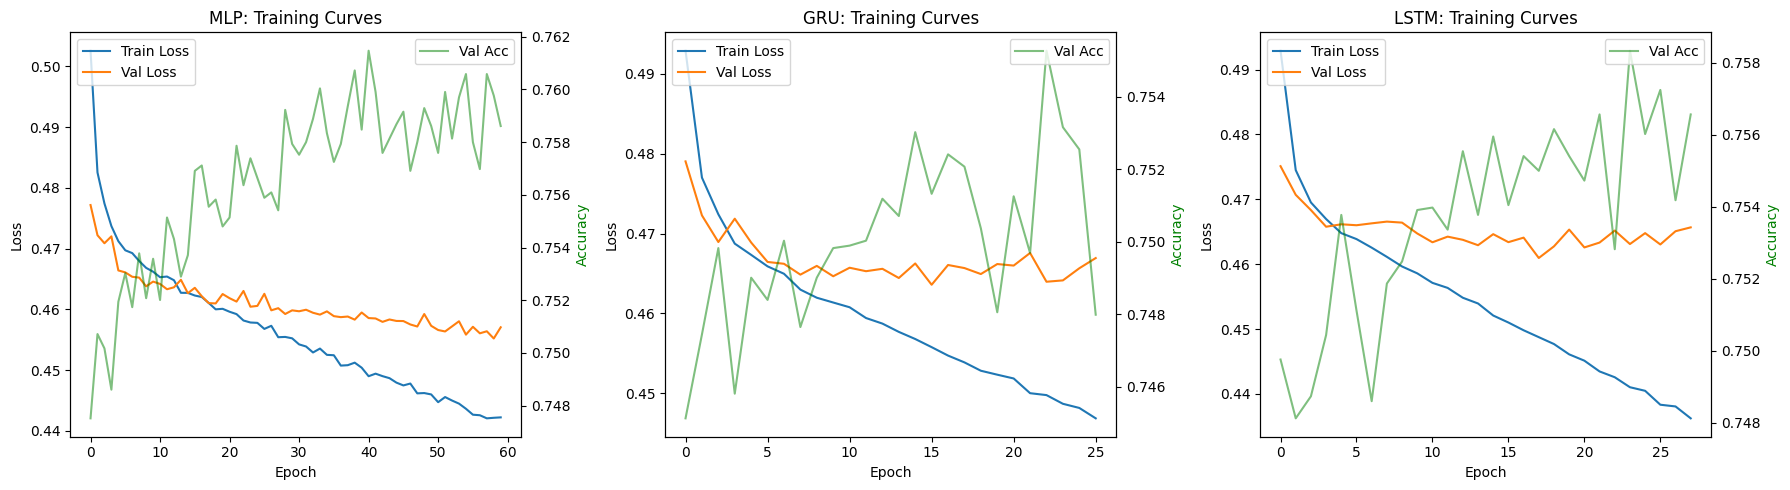

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
histories = {"MLP": mlp_hist, "GRU": gru_hist, "LSTM": lstm_hist}

for ax, (name, h) in zip(axes, histories.items()):
    ax.plot(h["train_loss"], label="Train Loss")
    ax.plot(h["val_loss"], label="Val Loss")
    ax2 = ax.twinx()
    ax2.plot(h["val_acc"], label="Val Acc", color="green", alpha=0.5)
    ax2.set_ylabel("Accuracy", color="green")
    ax.set_title(f"{name}: Training Curves")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

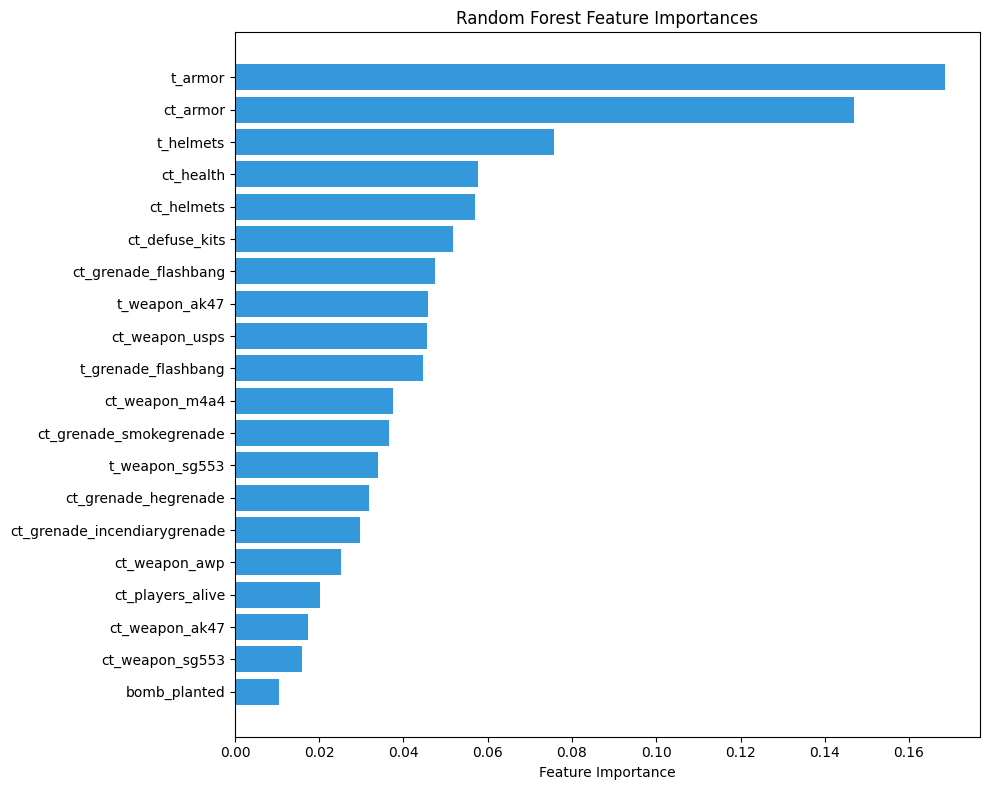

In [ ]:
# Feature importance (Random Forest)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
feat_names = [selected_features[i] for i in indices]
ax.barh(range(len(indices)), importances[indices], color="#3498db")
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(feat_names)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## Reports

In [18]:
for name, r in final.items():
    preds = (r["probs"] > 0.5).astype(int)
    print(f"\n{'='*53}")
    print(f"{name} (Accuracy: {r['acc']:.4f})")
    print(f"{'='*53}")
    print(classification_report(y_true, preds, target_names=["CT Win", "T Win"]))


Random Forest (Accuracy: 0.8315)
              precision    recall  f1-score   support

      CT Win       0.82      0.84      0.83     12004
       T Win       0.85      0.82      0.83     12478

    accuracy                           0.83     24482
   macro avg       0.83      0.83      0.83     24482
weighted avg       0.83      0.83      0.83     24482


MLP (Accuracy: 0.7599)
              precision    recall  f1-score   support

      CT Win       0.74      0.78      0.76     12004
       T Win       0.78      0.74      0.76     12478

    accuracy                           0.76     24482
   macro avg       0.76      0.76      0.76     24482
weighted avg       0.76      0.76      0.76     24482


GRU (Accuracy: 0.7502)
              precision    recall  f1-score   support

      CT Win       0.72      0.79      0.76     12004
       T Win       0.78      0.71      0.74     12478

    accuracy                           0.75     24482
   macro avg       0.75      0.75      0.75   

## Export Final Models

In [19]:
# save sklearn
joblib.dump(rf, MODEL_DIR / "rf_final.joblib")
joblib.dump(scaler, MODEL_DIR / "scaler_final.joblib")

# save pytorch
torch.save(mlp.state_dict(), MODEL_DIR / "mlp_final.pt")
torch.save(gru.state_dict(), MODEL_DIR / "gru_final.pt")
torch.save(lstm.state_dict(), MODEL_DIR / "lstm_final.pt")

# save model configs so the live server knows how to reconstruct them
model_configs = {
    "features": selected_features,
    "n_features": n_features,
    "mlp": {"hidden": mlp_p["hidden"]},
    "gru": {"hidden": gru_p["hidden"]},
    "lstm": {"hidden": lstm_p["hidden"]},
}
(MODEL_DIR / "model_configs.json").write_text(json.dumps(model_configs, indent=2))

print("saved")

saved
